# $\color{cyan}{\text{Imports and Setup}}$

## $\color{yellow}{\text{Imports}}$

In [1]:
# Enables automatic reloading of local analysis modules during notebook development
%load_ext autoreload
%autoreload 2

In [2]:
# Import required packages
import os
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scripts.sync import run_sync
from scripts.data_loader import load_titan_data
from scripts.setup_functions import run_pel_analysis, run_immob_analysis, run_standard_curve_analysis, four_pl, five_pl, curve_fit, analyse_standard_curves_extra
from scripts.analysis_functions import analyse_pel, analyse_immob_split, plot_pel_layer_shifts, combine_anomalies, analyse_cross_stage_split, cross_stage_correlations, create_interactive_dashboard, generate_at_risk_summary, run_binding_kinetics_analysis

## $\color{yellow}{\text{Setup}}$

In [3]:
# Configures pandas to show all dataframe columns without truncation
pd.set_option('display.max_columns', None)

### $\color{gold}{\text{Database Loading}}$

In [4]:
# Downloads datasets from the remote database (commented out to prevent redundant runs)
#run_sync()

In [5]:
# Load the processed Titan tables and storage-bucket datasets
tables, bucket_data = load_titan_data()

Loading database tables...
Loading table: amf_turns
Loading table: backend_event_log
Loading table: backend_event_log_archive
EMPTY FILE SKIPPED: backend_event_log_archive.csv
Loading table: chip_calibrations
Loading table: chip_calibration_spetrca
Loading table: chip_labelling
EMPTY FILE SKIPPED: chip_labelling.csv
Loading table: chip_status
Loading table: comments
Loading table: device
Loading table: experiments
Loading table: experiment_chips
Loading table: experiment_standard_curves
Loading table: flagged_items
Loading table: flags
Loading table: immob
Loading table: machine
Loading table: measurements
Loading table: notifications
Loading table: optical_reference_spectra
Loading table: pel_upload
Loading table: qc_baseline_drift
Loading table: qc_measurements
Loading table: sensorgram_history
Loading table: standard_curves
Loading table: standard_curve_history
Loading table: system_utilization_log
Loading table: uploads
Loading table: users
Loading and filtering bucket data...
SKIP

### $\color{gold}{\text{Fixing Flags}}$

In [6]:
def preprocess_PEL_flags(flags_PEL_df):
    '''Fills missing Finish flags using the last timestamp from the linked sensorgram.

    Args:
        flags_PEL_df (pd.DataFrame): The dataframe containing PEL flag records.

    Returns:
        pd.DataFrame: The processed dataframe with updated Finish flags.
    '''

    # Creates a copy of the PEL flags dataframe to preserve the original data
    flags_PEL_df = flags_PEL_df.copy()

    # Loops through each row in the dataframe
    for idx, flag_row in flags_PEL_df.iterrows():

        # Skips the current row if the Finish value is already populated
        if pd.notna(flag_row['Finish']):
            continue

        # Assigns the Final flag value to the missing Finish flag
        flags_PEL_df.at[idx, 'Finish'] = flags_PEL_df.at[idx, 'Final']

    # Returns the updated dataframe
    return flags_PEL_df

In [7]:
# Replace the raw PEL flag table with the processed version
tables['flags'] = preprocess_PEL_flags(tables['flags'])

In [8]:
# Creates an empty dictionary for averaged immobilisation flags if it does not already exist
if 'averaged_flags' not in bucket_data:
    bucket_data['averaged_flags'] = {}

# $\color{cyan}{\text{Initial Checks}}$

## $\color{yellow}{\text{Setup}}$

In [9]:
def evaluate_and_fix_swaps(tables, bucket_data, fix_mistakes=False):
    '''Validates matched PEL and immobilisation data for channel-order swaps.

    Args:
        tables (dict): Loaded database tables containing experiment metadata.
        bucket_data (dict): Loaded sensorgram and RefPoly4 file data.
        fix_mistakes (bool, optional): Whether detected swaps should be corrected in memory. Defaults to False.

    Returns:
        None: Results are reported to standard output and optional corrections are applied in place.
    '''

    # Initialises total variables for the channel-order comparison
    total_less_more = 0
    total_more_less = 0
    total_less = 0
    total_more = 0

    # Initialises variables to count PEL channel ordering
    all_pel_ch1_less = 0
    all_pel_ch2_less = 0
    all_pel_equal = 0
    total_pel_processed = 0

    # Initialises variables to count immobilisation channel ordering
    all_immob_ch1_less = 0
    all_immob_ch2_less = 0
    all_immob_equal = 0
    total_immob_processed = 0

    # Initialises variables to count matched PEL channel ordering
    matched_pel_ch1_less = 0
    matched_pel_ch2_less = 0
    matched_pel_equal = 0

    # Initialises variables to count matched immobilisation channel ordering
    matched_immob_ch1_less = 0
    matched_immob_ch2_less = 0
    matched_immob_equal = 0
    total_matched = 0

    # Initialises variables to count explained and unexplained channel swaps
    crossovers_explained_by_chemistry = 0
    crossovers_unexplained_true_swaps = 0

    # Initialises lists to store affected chip identifiers
    ch1_chemistry_chips = []
    ch1_unexplained_chips = []
    ch1_same_chips = []

    # Loops through each row in the PEL upload dataframe
    for index, pel_row in tables['pel_upload'].iterrows():

        # Extracts the flag and sensorgram identifiers for the current chip
        flags_id = pel_row['flags_id']
        sensorgram_file = pel_row['sensorgram']

        # Skips to the next record if the sensorgram file is not found in the bucket data
        if sensorgram_file not in bucket_data.get('Sensorgram', {}):
            continue
            
        pel_flags = tables['flags'][tables['flags']['flags_id'] == flags_id]

        # Checks whether the extracted flag dataframe contains data
        if pel_flags.empty:
            continue

        # Extracts the PEL signal values using the sensorgram data
        file_data = bucket_data['Sensorgram'][sensorgram_file]
        
        pel_start_time = pel_flags['Initial'].iloc[0] if isinstance(pel_flags['Initial'], pd.Series) else pel_flags['Initial']
        
        pel_start_1 = np.interp(pel_start_time, file_data['t'], file_data['quad_ch1'])
        pel_start_2 = np.interp(pel_start_time, file_data['t'], file_data['quad_ch2'])
        
        # Evaluates the initial channel order for the PEL record
        if pel_start_1 < pel_start_2:
            all_pel_ch1_less += 1
        elif pel_start_1 > pel_start_2:
            all_pel_ch2_less += 1
        else:
            all_pel_equal += 1
            
        total_pel_processed += 1

    # Loops through each row in the immobilisation dataframe
    for index, immob_row in tables['immob'].iterrows():

        chip_id = immob_row['chip_id']
        immob_flags_file = immob_row['amfFlags']
        refpoly4_file = immob_row['refPoly4']

        # Skips to the next record if the required files are missing from the bucket data
        if immob_flags_file not in bucket_data.get('AMF_FLAGS', {}) or refpoly4_file not in bucket_data.get('RefPoly4', {}):
            continue

        # Extracts the relevant flag and data tables for immobilisation
        immob_flags = bucket_data['AMF_FLAGS'][immob_flags_file]
        immob_data = bucket_data['RefPoly4'][refpoly4_file]

        # Checks whether the immobilisation flags dataframe contains valid information
        if immob_flags.empty or 'information' not in immob_flags.columns:
            continue

        initial_flags = immob_flags[immob_flags['information'].astype(str).str.contains('initial', case=False, na=False)]

        # Checks whether initial flags were successfully found
        if initial_flags.empty:
            continue
            
        # Calculates the starting values for the immobilisation channels
        immob_initial_time = initial_flags['time'].iloc[0]
        immob_start_1 = np.interp(immob_initial_time, immob_data['time'], immob_data['channel1'])
        immob_start_2 = np.interp(immob_initial_time, immob_data['time'], immob_data['channel2'])

        # Evaluates the initial channel order for the immobilisation record
        if immob_start_1 < immob_start_2:
            all_immob_ch1_less += 1
        elif immob_start_1 > immob_start_2:
            all_immob_ch2_less += 1
        else:
            all_immob_equal += 1
            
        total_immob_processed += 1

        # Searches for a corresponding PEL record using the chip identifier
        pel_match = tables['pel_upload'][tables['pel_upload']['chip_id'] == chip_id]
        
        # Skips to the next record if no matching PEL data exists
        if pel_match.empty:
            continue

        # Extracts the matched PEL metadata
        pel_row = pel_match.iloc[0]
        flags_id = pel_row['flags_id']
        sensorgram_file = pel_row['sensorgram']

        # Skips to the next record if the matched sensorgram file is not found
        if sensorgram_file not in bucket_data.get('Sensorgram', {}):
            continue

        # Retrieves the associated PEL flags
        pel_flags = tables['flags'][tables['flags']['flags_id'] == flags_id]

        # Checks whether the matched PEL flag dataframe contains data
        if pel_flags.empty:
            continue

        # Retrieves the associated PEL sensorgram data
        file_data = bucket_data['Sensorgram'][sensorgram_file]
    
        total_matched += 1

        # Extracts and calculates final comparative values across both experimental stages
        pel_start_time = pel_flags['Initial'].iloc[0] if isinstance(pel_flags['Initial'], pd.Series) else pel_flags['Initial']
        pel_final_time = pel_flags['Final'].iloc[0] if isinstance(pel_flags['Final'], pd.Series) else pel_flags['Final']
        
        pel_start_1 = np.interp(pel_start_time, file_data['t'], file_data['quad_ch1'])
        pel_start_2 = np.interp(pel_start_time, file_data['t'], file_data['quad_ch2'])
        
        pel_end_1 = np.interp(pel_final_time, file_data['t'], file_data['quad_ch1'])
        pel_end_2 = np.interp(pel_final_time, file_data['t'], file_data['quad_ch2'])

        # Increments counters for the matched PEL channel order
        if pel_start_1 < pel_start_2:
            matched_pel_ch1_less += 1
        elif pel_start_1 > pel_start_2:
            matched_pel_ch2_less += 1
        else:
            matched_pel_equal += 1

        # Increments counters for the matched immobilisation channel order
        if immob_start_1 < immob_start_2:
            matched_immob_ch1_less += 1
        elif immob_start_1 > immob_start_2:
            matched_immob_ch2_less += 1
        else:
            matched_immob_equal += 1

        # Analyses instances where Channel 1 starts lower in PEL but higher in immobilisation
        if pel_start_1 < pel_start_2 and immob_start_1 > immob_start_2:

            total_less_more += 1

            # Checks if the crossover is explained by the chemistry (channels crossed during PEL)
            if pel_end_1 > pel_end_2:

                crossovers_explained_by_chemistry += 1
                ch1_chemistry_chips.append(chip_id)
            elif pel_end_1 < pel_end_2:

                crossovers_unexplained_true_swaps += 1
                ch1_unexplained_chips.append(chip_id)

                # Fixes the channel swap in memory if requested
                if fix_mistakes:
                    bucket_data['RefPoly4'][refpoly4_file][['channel1', 'channel2']] = bucket_data['RefPoly4'][refpoly4_file][['channel2', 'channel1']]
            else:
                ch1_same_chips.append(chip_id)
                
        # Analyses instances where Channel 1 starts higher in PEL but lower in immobilisation
        elif pel_start_1 > pel_start_2 and immob_start_1 < immob_start_2:

            total_more_less += 1

            # Checks if the crossover is explained by the chemistry
            if pel_end_1 < pel_end_2:
                crossovers_explained_by_chemistry += 1
                ch1_chemistry_chips.append(chip_id)
            elif pel_end_1 > pel_end_2:
                crossovers_unexplained_true_swaps += 1
                ch1_unexplained_chips.append(chip_id)

                # Fixes the channel swap in memory if requested
                if fix_mistakes:
                    bucket_data['RefPoly4'][refpoly4_file][['channel1', 'channel2']] = bucket_data['RefPoly4'][refpoly4_file][['channel2', 'channel1']]
            else:
                ch1_same_chips.append(chip_id)
                
        # Logs cases where the channel order is consistent across stages
        elif pel_start_1 < pel_start_2 and immob_start_1 < immob_start_2:
            total_less += 1
        else:
            total_more += 1

    # Prints summary output regarding processed records and potential swaps
    print(f'Total Valid PEL Records Processed: {total_pel_processed}')
    print(f'Total Valid Immob Records Processed: {total_immob_processed}')
    print(f'Number of those successfully matched together: {total_matched}')

    print('\n1. PEL (at Start Flag for ALL valid PEL records)')
    print(f'Ch1 < Ch2: {all_pel_ch1_less}')
    print(f'Ch1 > Ch2: {all_pel_ch2_less}')
    print(f'Ch1 = Ch2: {all_pel_equal}')

    print('\n2. Immob (at Initial Flag for ALL valid Immob records)')
    print(f'Ch1 < Ch2: {all_immob_ch1_less}')
    print(f'Ch1 > Ch2: {all_immob_ch2_less}')
    print(f'Ch1 = Ch2: {all_immob_equal}')

    print('\n3. PEL (at Start Flag for MATCHED records only)')
    print(f'Ch1 < Ch2: {matched_pel_ch1_less}')
    print(f'Ch1 > Ch2: {matched_pel_ch2_less}')
    print(f'Ch1 = Ch2: {matched_pel_equal}')

    print('\n4. Immob (at Initial Flag for MATCHED records only)')
    print(f'Ch1 < Ch2: {matched_immob_ch1_less}')
    print(f'Ch1 > Ch2: {matched_immob_ch2_less}')
    print(f'Ch1 = Ch2: {matched_immob_equal}')

    print('\nComparison (for matched records only)')
    print(f'Ch1 < → Ch1 >: {total_less_more}')
    print(f'Ch1 > → Ch1 <: {total_more_less}')
    print(f'Ch1 < → Ch1 <: {total_less}')
    print(f'Ch1 > → Ch1 >: {total_more}')

    print('\nCrossover Verification')
    print(f'Total Crossovers (Ch1 and Ch2 flipped between PEL and Immob): {total_less_more + total_more_less}')
    print(f'Explained by Chemistry (Channels correctly overtook each other by end of PEL): {crossovers_explained_by_chemistry}')
    print(ch1_chemistry_chips)
    print(f'Unexplained True Swaps (Channels stayed physically swapped): {crossovers_unexplained_true_swaps}')
    print(ch1_unexplained_chips)

    print(f'Converged (Channels ended at the exact same value in PEL, making crossover ambiguous): {len(ch1_same_chips)}')
    print(ch1_same_chips)
    
    if fix_mistakes:
        print(f'\nSTATUS: FIXED {crossovers_unexplained_true_swaps} TRUE SWAPS IN RefPoly4 DATA')

## $\color{yellow}{\text{Checking Channels}}$

In [10]:
# Runs the channel-swap validation in report-only mode without changing the source data
evaluate_and_fix_swaps(tables, bucket_data, fix_mistakes=False)

Total Valid PEL Records Processed: 188
Total Valid Immob Records Processed: 28
Number of those successfully matched together: 26

1. PEL (at Start Flag for ALL valid PEL records)
Ch1 < Ch2: 182
Ch1 > Ch2: 6
Ch1 = Ch2: 0

2. Immob (at Initial Flag for ALL valid Immob records)
Ch1 < Ch2: 16
Ch1 > Ch2: 12
Ch1 = Ch2: 0

3. PEL (at Start Flag for MATCHED records only)
Ch1 < Ch2: 26
Ch1 > Ch2: 0
Ch1 = Ch2: 0

4. Immob (at Initial Flag for MATCHED records only)
Ch1 < Ch2: 16
Ch1 > Ch2: 10
Ch1 = Ch2: 0

Comparison (for matched records only)
Ch1 < → Ch1 >: 10
Ch1 > → Ch1 <: 0
Ch1 < → Ch1 <: 16
Ch1 > → Ch1 >: 0

Crossover Verification
Total Crossovers (Ch1 and Ch2 flipped between PEL and Immob): 10
Explained by Chemistry (Channels correctly overtook each other by end of PEL): 0
[]
Unexplained True Swaps (Channels stayed physically swapped): 10
['B72604R8030', 'B72604R8037', 'B72604R8038', 'B72604R8039', 'B72604R8047', 'B72604R8057', 'B72604R8058', 'B72604R8053', 'B72604R8117', 'B72604R8011']
Con

## $\color{yellow}{\text{Fixing Channels}}$

In [11]:
# Optionally reruns channel-swap validation while applying approved corrections
#evaluate_and_fix_swaps(tables, bucket_data, fix_mistakes=True)

# $\color{orange}{\text{Basic Analysis}}$

## $\color{yellow}{\text{PEL}}$

In [12]:
# Runs the PEL analysis workflow and stores its derived datasets
pel_analysis = run_pel_analysis(tables['pel_upload'], bucket_data['Sensorgram'], tables['flags'])

## $\color{yellow}{\text{Immobilisation}}$

In [13]:
# Runs the immobilisation analysis workflow and stores its derived datasets
immob_analysis = run_immob_analysis(tables['immob'], bucket_data['RefPoly4'], bucket_data['AMF_FLAGS'], bucket_data['averaged_flags'])

KeyboardInterrupt: 

## $\color{yellow}{\text{Standard Curve}}$

In [ ]:
# Runs standard-curve fitting and quality analysis
sc_analysis = run_standard_curve_analysis(tables['standard_curves'])

# $\color{orange}{\text{Per Stage Summary}}$

## $\color{yellow}{\text{Data Extraction}}$

In [ ]:
# Unpacks the PEL analysis outputs into separate dataframes
pel_events, pel_changes, pel_intra, pel_events_norm, pel_pooled_norm, pel_pooled_change, pel_pooled_intra = pel_analysis

In [ ]:
# Unpacks the immobilisation outputs for each sampling and reagent split
(imp_events, imp_changes, imp_intra, imp_norm, imp_pooled_norm, imp_pooled_change, imp_pooled_intra,
 comb_events, comb_changes, comb_intra, comb_norm, comb_pooled_norm, comb_pooled_change, comb_pooled_intra,
 avg_imp_events, avg_imp_changes, avg_imp_intra, avg_imp_norm, avg_imp_pooled_norm, avg_imp_pooled_change, avg_imp_pooled_intra,
 avg_comb_events, avg_comb_changes, avg_comb_intra, avg_comb_norm, avg_comb_pooled_norm, avg_comb_pooled_change, avg_comb_pooled_intra) = immob_analysis

In [ ]:
# Extracts standard-curve metrics and indexes them by chip ID
sc_dict, sc_metrics = sc_analysis
sc_metrics = sc_metrics.set_index('chip_id')

## $\color{yellow}{\text{PEL Stage Analysis}}$

### $\color{red}{\text{Correlation Analysis}}$

In [ ]:
# Analyses pooled PEL signals to identify stage-level anomalies
pel_wide, pel_change_wide, pel_intra_wide, outlier_chips_abs_pel, outlier_chips_delta_pel, outlier_chips_intra_pel = analyse_pel(pel_pooled_norm, pel_pooled_change, pel_pooled_intra, val_col='Norm_Signal', change_col='Delta_Signal', intra_val_col='pooled_signal', title='PEL (Pooled Channels)')

### $\color{red}{\text{Shift per Layer Plot}}$

In [ ]:
# Visualises PEL signal shifts across layer transitions
plot_pel_layer_shifts(pel_changes)

## $\color{yellow}{\text{Immobilisation Stage Analysis}}$

### $\color{red}{\text{Immediate (Non-Combined)}}$

In [ ]:
# Analyses immediate non-combined immobilisation measurements for anomalies
wide_imp, wide_changes_imp, wide_intra_imp, outliers_imp_abs, outliers_imp_delta, outliers_imp_intra = analyse_immob_split(imp_pooled_norm, imp_pooled_change, imp_pooled_intra, split_name='Immediate (Non-Combined)', val_col='Norm_Signal', change_col='Delta_Signal', intra_val_col='pooled_signal', title='Immob Immediate Non-Comb (Pooled)')

### $\color{red}{\text{Immediate (Combined)}}$

In [ ]:
# Analyses immediate combined immobilisation measurements for anomalies
wide_comb, wide_changes_comb, wide_intra_comb, outliers_comb_abs, outliers_comb_delta, outliers_comb_intra = analyse_immob_split(comb_pooled_norm, comb_pooled_change, comb_pooled_intra, split_name='Immediate (Combined)', val_col='Norm_Signal', change_col='Delta_Signal', intra_val_col='pooled_signal', title='Immob Immediate Comb (Pooled)')

### $\color{red}{\text{5s Average (Non-Combined)}}$

In [ ]:
# Analyses five-second averaged non-combined immobilisation measurements for anomalies
wide_avg_imp, wide_changes_avg_imp, wide_intra_avg_imp, outliers_avg_imp_abs, outliers_avg_imp_delta, outliers_avg_imp_intra = analyse_immob_split(avg_imp_pooled_norm, avg_imp_pooled_change, avg_imp_pooled_intra, split_name='5s Average (Non-Combined)', val_col='Norm_Signal', change_col='Delta_Signal', intra_val_col='pooled_signal', title='Immob 5s Avg Non-Comb (Pooled)')

### $\color{red}{\text{5s Average (Combined)}}$

In [ ]:
# Analyses five-second averaged combined immobilisation measurements for anomalies
wide_avg_comb, wide_changes_avg_comb, wide_intra_avg_comb, outliers_avg_comb_abs, outliers_avg_comb_delta, outliers_avg_comb_intra = analyse_immob_split(avg_comb_pooled_norm, avg_comb_pooled_change, avg_comb_pooled_intra, split_name='5s Average (Combined)', val_col='Norm_Signal', change_col='Delta_Signal', intra_val_col='pooled_signal', title='Immob 5s Avg Comb (Pooled)')

## $\color{yellow}{\text{Combined Anomalies}}$

### $\color{red}{\text{Combined Anomalies (Pooled)}}$

In [ ]:
# Combines anomaly lists for each PEL and immobilisation analysis stream
pel_anomalies = combine_anomalies(outlier_chips_abs_pel, outlier_chips_delta_pel, outlier_chips_intra_pel, title='Combined Anomalies: PEL (Pooled)')

imp_anomalies = combine_anomalies(outliers_imp_abs, outliers_imp_delta, outliers_imp_intra, title='Combined Anomalies: Immob Immediate Non-Comb (Pooled)')

comb_anomalies = combine_anomalies(outliers_comb_abs, outliers_comb_delta, outliers_comb_intra, title='Combined Anomalies: Immob Immediate Comb (Pooled)')

avg_imp_anomalies = combine_anomalies(outliers_avg_imp_abs, outliers_avg_imp_delta, outliers_avg_imp_intra, title='Combined Anomalies: Immob 5s Avg Non-Comb (Pooled)')

avg_comb_anomalies = combine_anomalies(outliers_avg_comb_abs, outliers_avg_comb_delta, outliers_avg_comb_intra, title='Combined Anomalies: Immob 5s Avg Comb (Pooled)')

### $\color{red}{\text{Combined Immobilisation Anomalies}}$

In [ ]:
# Combines immediate and averaged immobilisation anomaly results
imd_anomalies = combine_anomalies(imp_anomalies, comb_anomalies, title='Combined Anomalies: All Immediate Immobilisation')
avg_anomalies = combine_anomalies(avg_imp_anomalies, avg_comb_anomalies, title='Combined Anomalies: All 5s Avg Immobilisation')
immob_anomalies = combine_anomalies(imd_anomalies, avg_anomalies, title='Combined Anomalies: All Immobilisation (Overall)')

### $\color{red}{\text{Combined PEL \& Immobilisation Anomalies}}$

In [ ]:
# Combines PEL and immobilisation anomalies into an overall result
overall_anomalies = combine_anomalies(pel_anomalies, immob_anomalies, title='Overall Total Anomalies (PEL + Immobilisation)')

## $\color{yellow}{\text{Standard Curve R² Validation}}$

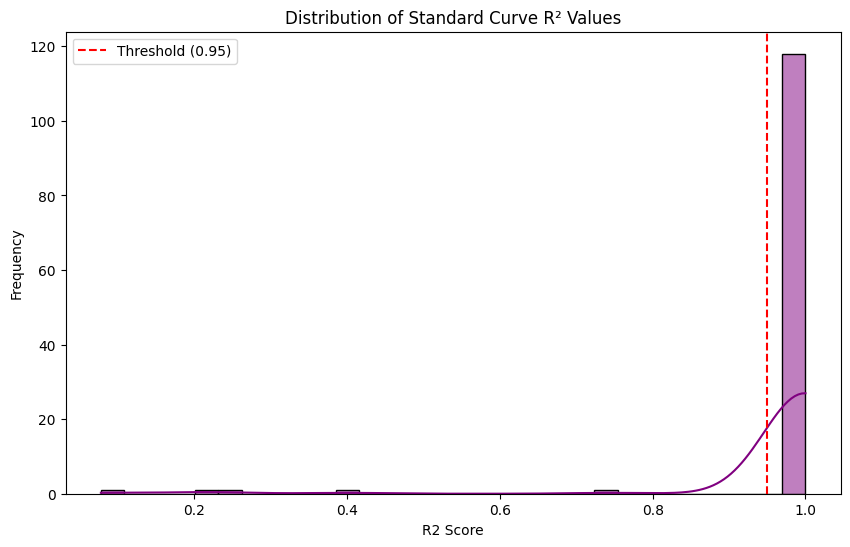

Total Standard Curves evaluated: 123
Average R² Score: 0.9719
Curves failing R² threshold (<0.95): 5

Chips associated with failed curves: ['B72604R8016', 'B72604R8030', 'B52501R8061', 'B72604R8038', 'B72604R8043']
--------------------------------------------------------------------------------
FAILED CURVE DETAILS & PLOTS
--------------------------------------------------------------------------------
Chip ID: B72604R8016 | Curve UUID: csb562a | R²: 0.2006


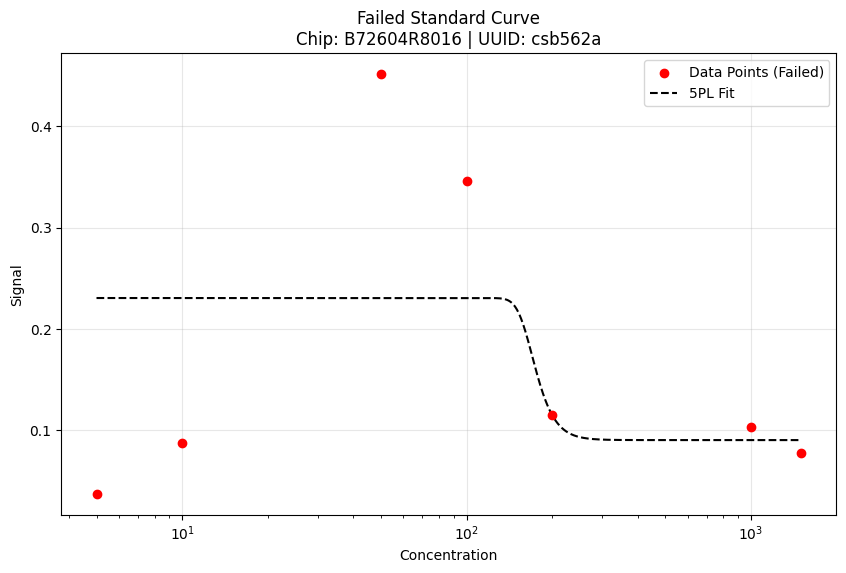

Chip ID: B72604R8030 | Curve UUID: cs36353 | R²: 0.4011


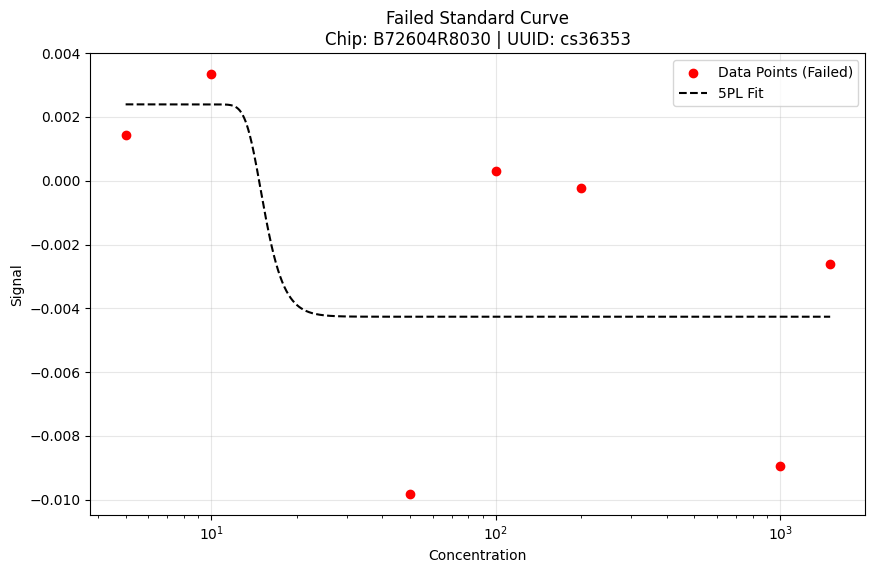

Chip ID: B52501R8061 | Curve UUID: cs84a80 | R²: 0.7446


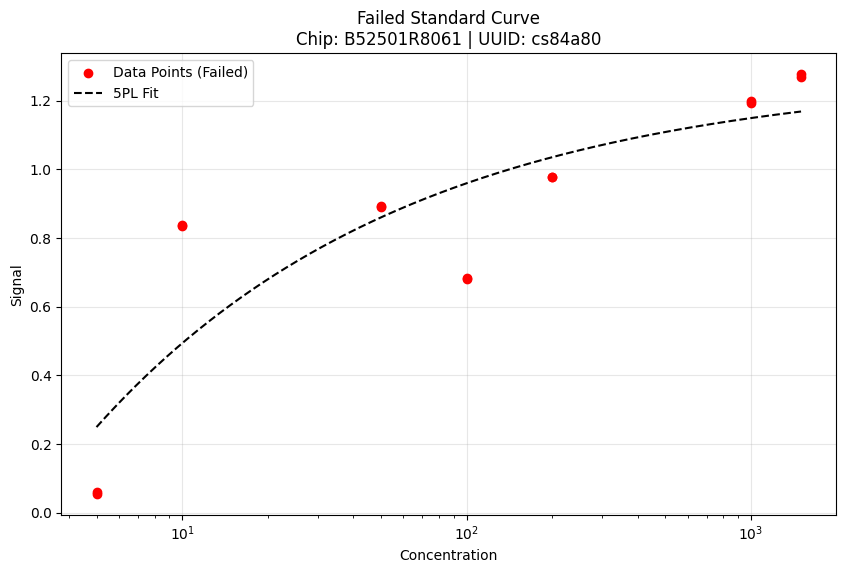

Chip ID: B72604R8038 | Curve UUID: cs2de12 | R²: 0.0775


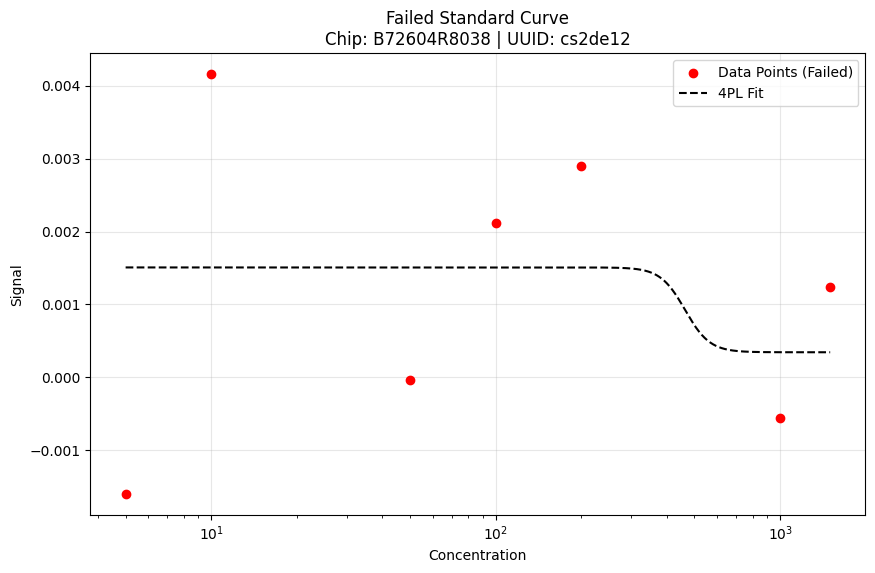

Chip ID: B72604R8043 | Curve UUID: cs419e1 | R²: 0.2325


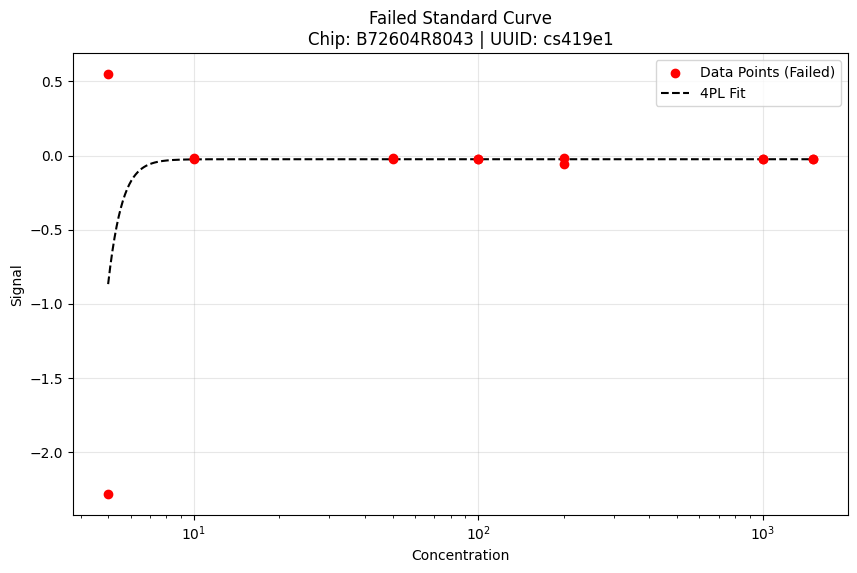

In [ ]:
# Evaluates standard-curve quality against the selected R-squared threshold
# Sets the minimum acceptable goodness-of-fit score for a standard curve
r2_threshold = 0.95

# Plots the distribution of standard-curve R-squared scores against the quality threshold
plt.figure(figsize=(10, 6))
sns.histplot(sc_metrics['r2'], bins=30, kde=True, color='purple')
plt.axvline(r2_threshold, color='red', linestyle='--', label=f'Threshold ({r2_threshold})')
plt.title('Distribution of Standard Curve R² Values')
plt.xlabel('R2 Score')
plt.ylabel('Frequency')
plt.legend()
plt.show()

# Identifies curves and chips that fall below the selected R-squared threshold
failing_curves = sc_metrics[sc_metrics['r2'] < r2_threshold]
failing_chips = failing_curves.index.unique().tolist()

print(f'Total Standard Curves evaluated: {len(sc_metrics)}')
print(f"Average R² Score: {sc_metrics['r2'].mean():.4f}")
print(f'Curves failing R² threshold (<{r2_threshold}): {len(failing_curves)}')

# Displays detailed diagnostics only when one or more curves fail the quality check
if failing_chips:
    print(f'\nChips associated with failed curves: {failing_chips}')

    print('-' * 80)
    print('FAILED CURVE DETAILS & PLOTS')
    print('-' * 80)
    
    # Plots the measured points and fitted curve for every failed standard curve
    for chip_id, row in failing_curves.iterrows():

        print(f"Chip ID: {chip_id} | Curve UUID: {row['standard_curve_uuid']} | R²: {row['r2']:.4f}")
        
        pts = np.array(row['points'])
        x_data, y_data = pts[:, 0], pts[:, 1]
        
        xfit = np.logspace(np.log10(min(x_data)), np.log10(max(x_data)), 1000)
        
        if row['fit_model'] == '5PL':
            yfit = five_pl(xfit, *row['parameters'])
        else:
            yfit = four_pl(xfit, *row['parameters'])
            
        # Plots the failed curve to show where the fitted model differs from the measured response
        plt.figure(figsize=(10, 6))
        plt.scatter(x_data, y_data, color='red', label='Data Points (Failed)', zorder=5)
        plt.plot(xfit, yfit, color='black', linestyle='--', label=f"{row['fit_model']} Fit")
        
        plt.xscale('log')
        plt.title(f"Failed Standard Curve\nChip: {chip_id} | UUID: {row['standard_curve_uuid']}")
        plt.xlabel('Concentration')
        plt.ylabel('Signal')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.show()

## $\color{yellow}{\text{Cross-Stage (PEL + Immob) Analysis}}$

### $\color{red}{\text{Anomalies Analysis}}$

#### $\color{lime}{\text{Immediate (Non-Combined)}}$

In [ ]:
# Compares PEL and immediate non-combined immobilisation signals using PCA
analyse_cross_stage_split(pel_wide, wide_imp, 'Immediate (Non-Combined)', pel_anomalies, imp_anomalies, sc_metrics, title='Cross-Stage PCA: Imm (Non-Comb)')

In [ ]:
# Compares PEL and immediate non-combined stage changes using PCA
analyse_cross_stage_split(pel_change_wide, wide_changes_imp, 'Immediate (Non-Combined) [Delta]', outlier_chips_delta_pel, outliers_imp_delta, sc_metrics, title='Cross-Stage PCA: Imm Non-Comb (Delta)')

In [ ]:
# Compares PEL and immediate non-combined kinetic features using PCA
analyse_cross_stage_split(pel_intra_wide, wide_intra_imp, 'Immediate (Non-Combined) [Intra]', outlier_chips_intra_pel, outliers_imp_intra, sc_metrics, title='Cross-Stage PCA: Imm Non-Comb (Intra)')

#### $\color{lime}{\text{Immediate (Combined)}}$

In [ ]:
# Compares PEL and immediate combined immobilisation signals using PCA
analyse_cross_stage_split(pel_wide, wide_comb, 'Immediate (Combined)', pel_anomalies, comb_anomalies, sc_metrics, title='Cross-Stage PCA: Immob Immediate Comb')

In [ ]:
# Compares PEL and immediate combined stage changes using PCA
analyse_cross_stage_split(pel_change_wide, wide_changes_comb, 'Immediate (Combined) [Delta]', outlier_chips_delta_pel, outliers_comb_delta, sc_metrics, title='Cross-Stage PCA: Imm Comb (Delta)')

In [ ]:
# Compares PEL and immediate combined kinetic features using PCA
analyse_cross_stage_split(pel_intra_wide, wide_intra_comb, 'Immediate (Combined) [Intra]', outlier_chips_intra_pel, outliers_comb_intra, sc_metrics, title='Cross-Stage PCA: Imm Comb (Intra)')

#### $\color{lime}{\text{5s Average (Non-Combined)}}$

In [ ]:
# Compares PEL and five-second non-combined immobilisation signals using PCA
analyse_cross_stage_split(pel_wide, wide_avg_imp, '5s Average (Non-Combined)', pel_anomalies, avg_imp_anomalies, sc_metrics, title='Cross-Stage PCA: Immob 5s Avg Non-Comb')

In [ ]:
# Compares PEL and five-second non-combined stage changes using PCA
analyse_cross_stage_split(pel_change_wide, wide_changes_avg_imp, '5s Average (Non-Combined) [Delta]', outlier_chips_delta_pel, outliers_avg_imp_delta, sc_metrics, title='Cross-Stage PCA: 5s Avg Non-Comb (Delta)')

In [ ]:
# Compares PEL and five-second non-combined kinetic features using PCA
analyse_cross_stage_split(pel_intra_wide, wide_intra_avg_imp, '5s Average (Non-Combined) [Intra]', outlier_chips_intra_pel, outliers_avg_imp_intra, sc_metrics, title='Cross-Stage PCA: 5s Avg Non-Comb (Intra)')

#### $\color{lime}{\text{5s Average (Combined)}}$

In [ ]:
# Compares PEL and five-second combined immobilisation signals using PCA
analyse_cross_stage_split(pel_wide, wide_avg_comb, '5s Average (Combined)', pel_anomalies, avg_comb_anomalies, sc_metrics, title='Cross-Stage PCA: Immob 5s Avg Comb')

In [ ]:
# Compares PEL and five-second combined stage changes using PCA
analyse_cross_stage_split(pel_change_wide, wide_changes_avg_comb, '5s Average (Combined) [Delta]', outlier_chips_delta_pel, outliers_avg_comb_delta, sc_metrics, title='Cross-Stage PCA: 5s Avg Comb (Delta)')

In [ ]:
# Compares PEL and five-second combined kinetic features using PCA
analyse_cross_stage_split(pel_intra_wide, wide_intra_avg_comb, '5s Average (Combined) [Intra]', outlier_chips_intra_pel, outliers_avg_comb_intra, sc_metrics, title='Cross-Stage PCA: 5s Avg Comb (Intra)')

### $\color{red}{\text{Correlations Analysis}}$

#### $\color{lime}{\text{Immediate (Non-Combined)}}$

In [ ]:
# Calculates cross-stage correlations for immediate non-combined absolute signals
cross_stage_correlations(pel_wide, wide_imp, 'Immediate (Non-Combined) [Abs]', sc_metrics, title='Cross-Stage Corr: Immob Immediate Non-Comb Abs')

In [ ]:
# Calculates cross-stage correlations for immediate non-combined stage changes
cross_stage_correlations(pel_change_wide, wide_changes_imp, 'Immediate (Non-Combined) [Delta]', sc_metrics, title='Cross-Stage Corr: Immob Immediate Non-Comb Delta')

In [ ]:
# Calculates cross-stage correlations for immediate non-combined kinetic features
cross_stage_correlations(pel_intra_wide, wide_intra_imp, 'Immediate (Non-Combined) [Intra]', sc_metrics, title='Cross-Stage Corr: Immob Immediate Non-Comb Intra')

#### $\color{lime}{\text{Immediate (Combined)}}$

In [ ]:
# Calculates cross-stage correlations for immediate combined absolute signals
cross_stage_correlations(pel_wide, wide_comb, 'Immediate (Combined) [Abs]', sc_metrics, title='Cross-Stage Corr: Immob Immediate Comb Abs')

In [ ]:
# Calculates cross-stage correlations for immediate combined stage changes
cross_stage_correlations(pel_change_wide, wide_changes_comb, 'Immediate (Combined) [Delta]', sc_metrics, title='Cross-Stage Corr: Immob Immediate Comb Delta')

In [ ]:
# Calculates cross-stage correlations for immediate combined kinetic features
cross_stage_correlations(pel_intra_wide, wide_intra_comb, 'Immediate (Combined) [Intra]', sc_metrics, title='Cross-Stage Corr: Immob Immediate Comb Intra')

#### $\color{lime}{\text{5s Average (Non-Combined)}}$

In [ ]:
# Calculates cross-stage correlations for five-second non-combined absolute signals
cross_stage_correlations(pel_wide, wide_avg_imp, '5s Average (Non-Combined) [Abs]', sc_metrics, title='Cross-Stage Corr: Immob 5s Avg Non-Comb Abs')

In [ ]:
# Calculates cross-stage correlations for five-second non-combined stage changes
cross_stage_correlations(pel_change_wide, wide_changes_avg_imp, '5s Average (Non-Combined) [Delta]', sc_metrics, title='Cross-Stage Corr: Immob 5s Avg Non-Comb Delta')

In [ ]:
# Calculates cross-stage correlations for five-second non-combined kinetic features
cross_stage_correlations(pel_intra_wide, wide_intra_avg_imp, '5s Average (Non-Combined) [Intra]', sc_metrics, title='Cross-Stage Corr: Immob 5s Avg Non-Comb Intra')

#### $\color{lime}{\text{5s Average (Combined)}}$

In [ ]:
# Calculates cross-stage correlations for five-second combined absolute signals
cross_stage_correlations(pel_wide, wide_avg_comb, '5s Average (Combined) [Abs]', sc_metrics, title='Cross-Stage Corr: Immob 5s Avg Comb Abs')

In [ ]:
# Calculates cross-stage correlations for five-second combined stage changes
cross_stage_correlations(pel_change_wide, wide_changes_avg_comb, '5s Average (Combined) [Delta]', sc_metrics, title='Cross-Stage Corr: Immob 5s Avg Comb Delta')

In [ ]:
# Calculates cross-stage correlations for five-second combined kinetic features
cross_stage_correlations(pel_intra_wide, wide_intra_avg_comb, '5s Average (Combined) [Intra]', sc_metrics, title='Cross-Stage Corr: Immob 5s Avg Comb Intra')

## $\color{yellow}{\text{Interactive Stage Comparison Dashboards}}$

### $\color{red}{\text{Setup}}$

In [ ]:
# Copies the fit metrics so the original standard-curve results remain unchanged
sc_copy = sc_metrics.copy()
sc_copy.columns = sc_copy.columns.astype(str)

# Selects only numeric fit metrics that can be compared with the stage-analysis datasets
numeric_cols = sc_copy.select_dtypes(include='number').columns.tolist()

# Retains the timestamp temporarily so the first curve for each chip can be selected
if 'datetime' in sc_copy.columns:
    sc_copy = sc_copy[['datetime'] + numeric_cols]
else:
    sc_copy = sc_copy[numeric_cols]

# Keeps the first standard-curve record per chip for cross-stage comparisons
sc_first = sc_copy.sort_values('datetime').groupby(sc_copy.index, sort=False).first().drop(columns='datetime')

In [ ]:
# Builds a catalog of analysis datasets for the interactive dashboard
master_data_catalog = {

    # Stores absolute-signal datasets for dashboard comparisons
    'Absolute': {
        'PEL': pel_wide,
        'Immob (Imm, Non-Comb)': wide_imp,
        'Immob (Imm, Comb)': wide_comb,
        'Immob (5s, Non-Comb)': wide_avg_imp,
        'Immob (5s, Comb)': wide_avg_comb,
        'Standard Curve': sc_first 
    },

    # Stores stage-to-stage signal-change datasets for dashboard comparisons
    'Stage Delta': {
        'PEL': pel_change_wide,
        'Immob (Imm, Non-Comb)': wide_changes_imp,
        'Immob (Imm, Comb)': wide_changes_comb,
        'Immob (5s, Non-Comb)': wide_changes_avg_imp,
        'Immob (5s, Comb)': wide_changes_avg_comb,
        'Standard Curve': sc_first
    },
    
    # Stores within-stage kinetic feature datasets for dashboard comparisons
    'Intra-stage Kinetics': {
        'PEL': pel_intra_wide,
        'Immob (Imm, Non-Comb)': wide_intra_imp,
        'Immob (Imm, Comb)': wide_intra_comb,
        'Immob (5s, Non-Comb)': wide_intra_avg_imp,
        'Immob (5s, Comb)': wide_intra_avg_comb,
        'Standard Curve': sc_first
    }
}

### $\color{red}{\text{Display}}$

In [ ]:
# Launches the interactive cross-stage data exploration dashboard
create_interactive_dashboard(master_data_catalog)

HTML(value="<h3 style='margin-bottom:0px; color:#0000FF;'>Master Chip Comparison Dashboard</h3>")

Output()

# $\color{orange}{\text{Overall Summary}}$

## $\color{yellow}{\text{Setup}}$

In [ ]:
# Groups analysis outputs and anomaly lists by experimental section
section_config = {
    
    # Links PEL signal, change, and kinetic tables to their matching anomaly lists
    'PEL Absolute': (pel_wide, outlier_chips_abs_pel),
    'PEL Delta': (pel_change_wide, outlier_chips_delta_pel),
    'PEL Intra-stage': (pel_intra_wide, outlier_chips_intra_pel),

    # Links immediate immobilisation tables to their matching anomaly lists
    'Immob Immediate Abs (Non-Comb)': (wide_imp, outliers_imp_abs),
    'Immob Immediate Delta (Non-Comb)': (wide_changes_imp, outliers_imp_delta),
    'Immob Immediate Intra (Non-Comb)': (wide_intra_imp, outliers_imp_intra),

    'Immob Immediate Abs (Comb)': (wide_comb, outliers_comb_abs),
    'Immob Immediate Delta (Comb)': (wide_changes_comb, outliers_comb_delta),
    'Immob Immediate Intra (Comb)': (wide_intra_comb, outliers_comb_intra),

    # Links five-second averaged immobilisation tables to their matching anomaly lists
    'Immob 5s Avg Abs (Non-Comb)': (wide_avg_imp, outliers_avg_imp_abs),
    'Immob 5s Avg Delta (Non-Comb)': (wide_changes_avg_imp, outliers_avg_imp_delta),
    'Immob 5s Avg Intra (Non-Comb)': (wide_intra_avg_imp, outliers_avg_imp_intra),

    'Immob 5s Avg Abs (Comb)': (wide_avg_comb, outliers_avg_comb_abs),
    'Immob 5s Avg Delta (Comb)': (wide_changes_avg_comb, outliers_avg_comb_delta),
    'Immob 5s Avg Intra (Comb)': (wide_intra_avg_comb, outliers_avg_comb_intra)
}

In [ ]:
# Collects every chip identified as anomalous or chips with a standard-curve at risk
all_at_risk_chips = set(failing_chips)

# Loops through each section configuration to aggregate outlier chips
for _, outliers in section_config.values():
    all_at_risk_chips.update(outliers)

In [ ]:
# Standardises channel labels before combining multi-channel datasets
channel_mapping = {
    'quad_ch1': 'Ch1', 'channel1': 'Ch1',
    'quad_ch2': 'Ch2', 'channel2': 'Ch2',
    'quad_ch1_change': 'Ch1', 'channel1_change': 'Ch1',
    'quad_ch2_change': 'Ch2', 'channel2_change': 'Ch2'
}

In [ ]:
# Combines complete analysis features into a single chip-level dataset
# Collects compatible feature tables before joining them into one chip-level dataset
dfs_to_concat = []

# Loops through each key and value in the dictionary
for name, (df, _) in section_config.items():

    # Includes only populated tables so empty analysis sections do not remove valid chips
    if not df.empty:
        
        # Creates a copy of the dataframe to preserve original data
        df_mapped = df.copy()

        # Standardises MultiIndex channel labels before the feature tables are joined
        if isinstance(df_mapped.index, pd.MultiIndex) and 'Channel' in df_mapped.index.names:
            df_mapped = df_mapped.rename(index=channel_mapping, level='Channel')
            
        # Keeps each feature name unique by adding its analysis-section label
        dfs_to_concat.append(df_mapped.add_suffix(f"_{name.replace(' ', '_')}"))

# Joins features shared by every available chip into the master comparison table
master_df = pd.concat(dfs_to_concat, axis=1, join='inner').dropna()

## $\color{yellow}{\text{Chips That May Fail}}$

In [ ]:
# Generates a detailed summary of at-risk chips and their anomaly drivers
generate_at_risk_summary(master_df, sc_metrics, tables['standard_curves'], all_at_risk_chips, section_config, title='At-Risk Chips & Anomaly Drivers')

# $\color{orange}{\text{Standard Curve Extra Data}}$

## $\color{yellow}{\text{Getting SC Data}}$

In [ ]:
# Loads local standard-curve CSV files into a structured dictionary
# Sets the directory containing exported standard-curve measurements
base_dir = "Standard Curve Files"

# Creates a nested dictionary to organise files by their export folder
files = {}

# Loops through each export folder and loads its CSV measurements
for folder in os.listdir(base_dir):

    # Builds the full path for the current export folder
    folder_path = os.path.join(base_dir, folder)

    # Checks if the folder path exists
    if os.path.isdir(folder_path):
        files[folder] = {}

        # Loops through each CSV candidate in the current export folder
        for file in os.listdir(folder_path):

            # Builds the full path for the current CSV file
            file_path = os.path.join(folder_path, file)

            # Loads CSV files only because they contain the standard-curve measurements
            if file.endswith(".csv"):
                
                # Removes the extension so the dictionary key matches the measurement name
                file_name = os.path.splitext(file)[0]

                df = pd.read_csv(file_path)

                # Repairs missing sensorgram headers so channel data can be analysed consistently
                if "sensorgram" in file_name.lower():
                    expected = ['time', "channel1", "channel2"]

                    if list(df.columns[:2]) != expected:
                        df = pd.read_csv(file_path, header=None)
                        df.columns = expected

                # Stores the loaded dataframe under its folder and measurement name
                files[folder][file_name] = df

## $\color{yellow}{\text{Basic Analysis}}$

In [ ]:
# Runs extended standard-curve visualisations and baseline-shift analysis
files = analyse_standard_curves_extra(files)


Evaluating Folder: 2026-04-13

--- Chip ID: B52501R8242 | Measurement ID: csa5eb7 ---



--- Chip ID: B52501R8242 | Measurement ID: csda3af ---



Evaluating Folder: 2026-04-15

--- Chip ID: B52501R8242 | Measurement ID: cs5dbc5 ---



Evaluating Folder: 2026-04-16

--- Chip ID: B52501R8242 | Measurement ID: cs3142c ---


## $\color{yellow}{\text{Binding Kinetics}}$

In [ ]:
# Runs association and dissociation binding-kinetics analysis
kinetics_results = run_binding_kinetics_analysis(files)


Kinetics Analysis: 2026-04-13



--- Chip ID: B52501R8242 | Measurement ID: csa5eb7 ---



--- Chip ID: B52501R8242 | Measurement ID: csda3af ---



Kinetics Analysis: 2026-04-15



--- Chip ID: B52501R8242 | Measurement ID: cs5dbc5 ---



Kinetics Analysis: 2026-04-16



--- Chip ID: B52501R8242 | Measurement ID: cs3142c ---


# $\color{cyan}{\text{Run Check}}$

In [ ]:
# Confirms that the primary analysis workflow has completed
print('run completed')

run completed


## $\color{yellow}{\text{Seperate}}$

In [ ]:
# Counts the initial channel ordering across PEL sensorgram files
total_ch1_less = 0
total_ch2_less = 0
total_equal = 0

# Loops through each key and value in the dictionary
for file_name, file_data in bucket_data['Sensorgram'].items():

    if file_data['quad_ch1'].iloc[0] < file_data['quad_ch2'].iloc[0]:
        total_ch1_less += 1
    elif file_data['quad_ch1'].iloc[0] > file_data['quad_ch2'].iloc[0]:
        total_ch2_less += 1
    else:
        total_equal += 1

# Prints Summary
print('Ch1 < Ch2: ', total_ch1_less)
print('Ch1 > Ch2: ', total_ch2_less)
print('Ch1 = Ch2: ', total_equal)

Ch1 < Ch2:  185
Ch1 > Ch2:  9
Ch1 = Ch2:  4


In [ ]:
# Counts the initial channel ordering across RefPoly4 immobilisation files
total_ch1_less = 0
total_ch2_less = 0
total_equal = 0

# Loops through each key and value in the dictionary
for file_name, file_data in bucket_data['RefPoly4'].items():

    if file_data['channel1'].iloc[0] < file_data['channel2'].iloc[0]:
        total_ch1_less += 1
    elif file_data['channel1'].iloc[0] > file_data['channel2'].iloc[0]:
        total_ch2_less += 1
    else:
        total_equal += 1

# Prints Summary
print('Ch1 < Ch2: ', total_ch1_less)
print('Ch1 > Ch2: ', total_ch2_less)
print('Ch1 = Ch2: ', total_equal)

Ch1 < Ch2:  16
Ch1 > Ch2:  12
Ch1 = Ch2:  0


## $\color{yellow}{\text{Overall}}$

In [ ]:
# Initialises variables to track channel-order changes between matched records
total_less_more = 0
total_more_less = 0
total_less = 0
total_more = 0

# Initialises variables to count initial PEL channel ordering
pel_ch1_less = 0
pel_ch2_less = 0
pel_equal = 0

# Initialises variables to count initial immobilisation channel ordering
immob_ch1_less = 0
immob_ch2_less = 0
immob_equal = 0

# Initialises variables to track record matching success
total_not_matched = 0
total_matched = 0

# Initialises variables to count explained and unexplained channel swaps
crossovers_explained_by_chemistry = 0
crossovers_unexplained_true_swaps = 0

# Initialises lists to store affected chip identifiers
ch1_chemistry_chips = []
ch1_unexplained_chips = []
ch1_same_chips = []

# Loops through each row in the PEL upload dataframe
for index, pel_row in tables['pel_upload'].iterrows():

    # Extracts the chip, flag, and sensorgram identifiers
    chip_id = pel_row['chip_id']
    flags_id = pel_row['flags_id']
    sensorgram_file = pel_row['sensorgram']

    # Skips to the next record if the sensorgram file is not found in the bucket data
    if sensorgram_file not in bucket_data['Sensorgram'].keys():
        total_not_matched += 1
        continue
        
    # Retrieves the associated sensorgram data
    file_data = bucket_data['Sensorgram'][sensorgram_file]

    # Searches for a corresponding immobilisation record using the chip identifier
    refpoly4_match = tables['immob'][tables['immob']['chip_id'] == chip_id]

    # Checks whether the matched immobilisation dataframe contains data
    if refpoly4_match.empty:
        total_not_matched += 1
        continue

    # Extracts the matched immobilisation metadata
    immob_row = refpoly4_match.iloc[0]
    immob_flags_file = immob_row['amfFlags']
    
    # Retrieves the associated immobilisation flags
    immob_flags = bucket_data['AMF_FLAGS'].get(immob_flags_file, pd.DataFrame())

    # Sets a boolean flag to verify the presence of 'prg' reagent
    has_prg = False

    # Checks whether the immobilisation flags dataframe contains valid information
    if not immob_flags.empty and 'information' in immob_flags.columns:

        # Evaluates if any row contains the 'prg' identifier
        has_prg = any('prg' in str(row.information).lower() for row in immob_flags.itertuples())
        
    # Skips to the next record if 'prg' is not present
    if not has_prg:
        total_not_matched += 1
        continue

    # Retrieves the associated PEL flags
    pel_flags = tables['flags'][tables['flags']['flags_id'] == flags_id]

    # Checks whether the flag dataframes contain data
    if pel_flags.empty or immob_flags.empty:
        total_not_matched += 1
        continue

    # Increments the matched records counter
    total_matched += 1

    # Retrieves the associated RefPoly4 data
    refpoly4_file = immob_row['refPoly4']
    immob_data = bucket_data['RefPoly4'][refpoly4_file]

    # Extracts the relevant timing flags for comparison
    pel_start_time = pel_flags['Initial']
    pel_final_time = pel_flags['Final']
    immob_initial_time = immob_flags[immob_flags['information'].str.contains('initial', case=False, na=False)]['time'].iloc[0]

    # Interpolates PEL signal values at the start time
    pel_start_1 = np.interp(pel_start_time, file_data['t'], file_data['quad_ch1'])
    pel_start_2 = np.interp(pel_start_time, file_data['t'], file_data['quad_ch2'])
    
    # Interpolates PEL signal values at the final time
    pel_end_1 = np.interp(pel_final_time, file_data['t'], file_data['quad_ch1'])
    pel_end_2 = np.interp(pel_final_time, file_data['t'], file_data['quad_ch2'])
    
    # Interpolates immobilisation signal values at the initial time
    immob_start_1 = np.interp(immob_initial_time, immob_data['time'], immob_data['channel1'])
    immob_start_2 = np.interp(immob_initial_time, immob_data['time'], immob_data['channel2'])

    # Evaluates the initial channel order for the PEL record
    if pel_start_1 < pel_start_2:
        pel_ch1_less += 1
    elif pel_start_1 > pel_start_2:
        pel_ch2_less += 1
    else:
        pel_equal += 1

    # Evaluates the initial channel order for the immobilisation record
    if immob_start_1 < immob_start_2:
        immob_ch1_less += 1
    elif immob_start_1 > immob_start_2:
        immob_ch2_less += 1
    else:
        immob_equal += 1

    # Analyses instances where Channel 1 starts lower in PEL but higher in immobilisation
    if pel_start_1 < pel_start_2 and immob_start_1 > immob_start_2:
        total_less_more += 1
        
        # Checks if the crossover is explained by the chemistry (channels crossed during PEL)
        if pel_end_1 > pel_end_2:
            crossovers_explained_by_chemistry += 1
            ch1_chemistry_chips.append(chip_id)
            
        # Identifies true unexplained swaps
        elif pel_end_1 < pel_end_2:
            crossovers_unexplained_true_swaps += 1
            ch1_unexplained_chips.append(chip_id)
            
        # Categorises ambiguous cases where channels converge
        else:
            ch1_same_chips.append(chip_id)

    # Analyses instances where Channel 1 starts higher in PEL but lower in immobilisation
    elif pel_start_1 > pel_start_2 and immob_start_1 < immob_start_2:
        total_more_less += 1
        
    # Logs cases where the channel order is consistent across stages
    elif pel_start_1 < pel_start_2 and immob_start_1 < immob_start_2:
        total_less += 1
    else:
        total_more += 1

# Prints summary output regarding processed records and potential swaps
print(f'Number of matching PEL and Immob records for PrG: {total_matched}')
print(f'Number of unmatched records: {total_not_matched}')

print('\nPEL (at Start Flag)')
print(f'Ch1 < Ch2: {pel_ch1_less}')
print(f'Ch1 > Ch2: {pel_ch2_less}')
print(f'Ch1 = Ch2: {pel_equal}')

print('\nImmob (at Initial Flag)')
print(f'Ch1 < Ch2: {immob_ch1_less}')
print(f'Ch1 > Ch2: {immob_ch2_less}')
print(f'Ch1 = Ch2: {immob_equal}')

print('\nComparison')
print(f'Ch1 < → Ch1 >: {total_less_more}')
print(f'Ch1 > → Ch1 <: {total_more_less}')
print(f'Ch1 < → Ch1 <: {total_less}')
print(f'Ch1 > → Ch1 >: {total_more}')

print('\nCrossover Verification')
print(f'Total Crossovers (Ch1 started lower in PEL, but higher in Immob): {total_less_more}')
print(f'Explained by Chemistry (Ch1 overtook Ch2 by end of PEL): {crossovers_explained_by_chemistry}')
print(ch1_chemistry_chips)

print(f'Unexplained (True channel swaps between physical stages): {crossovers_unexplained_true_swaps}')
print(ch1_unexplained_chips)

print(f'Ch1 and Ch2 ended same: {len(ch1_same_chips)}')
print(ch1_same_chips)

Number of matching PEL and Immob records for PrG: 26
Number of unmatched records: 162

PEL (at Start Flag)
Ch1 < Ch2: 26
Ch1 > Ch2: 0
Ch1 = Ch2: 0

Immob (at Initial Flag)
Ch1 < Ch2: 16
Ch1 > Ch2: 10
Ch1 = Ch2: 0

Comparison
Ch1 < → Ch1 >: 10
Ch1 > → Ch1 <: 0
Ch1 < → Ch1 <: 16
Ch1 > → Ch1 >: 0

Crossover Verification
Total Crossovers (Ch1 started lower in PEL, but higher in Immob): 10
Explained by Chemistry (Ch1 overtook Ch2 by end of PEL): 0
[]
Unexplained (True channel swaps between physical stages): 10
['B72604R8030', 'B72604R8039', 'B72604R8011', 'B72604R8037', 'B72604R8038', 'B72604R8047', 'B72604R8053', 'B72604R8057', 'B72604R8058', 'B72604R8117']
Ch1 and Ch2 ended same: 0
[]
